# nb_AJ — Thomas et al. (2018), one to one: their method on their data with their exclusions, then on Switchboard sides

**What this notebook records.** The step-for-step replication of Thomas, Czerwinski, McDuff, Craswell & Mark, *Style and Alignment in Information-Seeking Conversation* (CHIIR '18, [doi:10.1145/3176349.3176388](https://doi.org/10.1145/3176349.3176388); author PDF at [microsoft.com/research](https://www.microsoft.com/en-us/research/wp-content/uploads/2018/01/chiirfp025-thomasA.pdf)), §3.2–§4.1: the eleven stylistic variables, the §3.4 data cleaning applied **by the cases the paper names**, z-scoring, Cronbach's α, Revelle's GLB computed **by the routine the paper's footnote 2 names** (psych 1.7.3 `glb.fa`, ported from the CRAN source), the PCA whose first component is Table 2, the involvement score, and the distribution of units on that component with fitted curves. The same method is then run on Switchboard conversation sides, the paper's unit on our corpus. §8 (added 2026-10-06) asks whether Horn's five Switchboard components survive other retention criteria: Velicer's MAP, the empirical Kaiser criterion and comparison data.

**Inputs.** `c_alpha/misc_variables_all.csv` — the eleven computed on the MISC release along the paper's own routes (`c_alpha/misc_variables.py`: STT lines as utterances, OpenSMILE `prosodyShs` F0/loudness tracks); `../utterances_v2/derived/thomas2018_side.csv` — the eleven per Switchboard side (`swb-extract thomas2018-side`, `src/swb_extract/features/thomas2018/`). Every statistic is a function in `c_alpha/thomas_method.py` (tested in `tests/test_c_alpha_method.py`); that script's CSV outputs are the same numbers in file form. The running record is `c_alpha/README.md`; the audit entry is `docs/AUDIT.md` §4E-h.

Run from `analysis/`: `python3 -m jupyter nbconvert --to notebook --execute --inplace nb_AJ.ipynb` (about a minute and a half; §8's simulations take most of it).

In [1]:
# nb_AJ provenance + imports. cwd must be analysis/ (../ = repo root), as for NB08.
import datetime, importlib.util, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd, scipy, matplotlib.pyplot as plt
from scipy import stats
import diptest

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())
sys.path.insert(0, str(ROOT / "src"))
spec = importlib.util.spec_from_file_location("tm", ROOT / "analysis/c_alpha/thomas_method.py")
tm = importlib.util.module_from_spec(spec); spec.loader.exec_module(tm)      # every statistic below is a tm function
V = list(tm.VARIABLES)                                                        # paper order: ppron … repu
T2 = np.array([tm.PAPER_LOADINGS[v] for v in V])                              # Table 2
KEY = np.array([-1 if v in tm.KEY_NEGATIVE else 1 for v in V])                # Table 2's signs: boplen, poplen, olap negative
head = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True, cwd=ROOT).stdout.strip()
pd.set_option("display.width", 400); pd.set_option("display.precision", 3); pd.set_option("display.max_colwidth", 80)
print(f"nb_AJ · {datetime.date.today()} · repo HEAD {head} · python {sys.version.split()[0]} · numpy {np.__version__} · scipy {scipy.__version__} · Table 2 weights: Σw² = {(T2**2).sum():.3f}")

nb_AJ · 2026-10-06 · repo HEAD 0efd102 · python 3.14.0 · numpy 2.4.4 · scipy 1.17.1 · Table 2 weights: Σw² = 1.005


## 1 — The paper's recipe, quoted

Each step below copies the sentence it implements. Page references are to the author PDF.

**Variables (§3.2).** "For each participant in each task, we derived eleven variables in six categories": ppron, wps, wpu, wpp, boplen, poplen, pv, lv, olap, rept, repu (definitions, verbatim from the paper, in `src/swb_extract/features/thomas2018/__init__.py`). "An 'utterance' here is simply a line of transcript."

**Scaling (§3.2).** "The eleven variables are on very different scales … so in the analysis below they are each rescaled to zero mean, unit standard deviation. Inspection confirmed that each variable is approximately normal, although some have long tails."

**Cleaning (§3.4).** "We examined all apparent outliers, across all the variables discussed above, and removed a small number of cases." The cases: *participant 2, transport task* (post-other pauses "mean more than 20 s, with two of almost 1 min out of only seven"); *participant 5, migraine and Olympics tasks* ("spoke slowly with very high overlap", the overlaps mostly "um", "uh", "uh-huh"); *participants 17 and 18, transport task* (17 "deciding on an answer early, with no attempt to search", 18 "never offers any information … speaks 80 of the 1040 words"). Then: "we also removed any task that had recordings past the ten-minute mark. This left us with observations from 98 participant-tasks."

**Reliability (§4.1).** "Revelle's GLB is 0.85 over all eleven variables and 168 observations, suggesting good reliability (corresponding Cronbach's α = 0.67)." Footnote 2 (p. 4): "GLB is the `glb.fa` greatest lower bound of Revelle [21]" — the psych R package, version 1.7.3 — "which we use in this work as some of our variables are not symmetric and in general they may load differently."

**Component (§4.1).** "A principal components analysis and scree plot suggested one more important component, explaining 29% of variance, and 2–3 less important components each explaining 14% or less. This first principal component is summarised in Table 2." Table 2, loadings on "involvement": ppron .13 · wps .39 · wpu .45 · wpp .44 · boplen −.10 · poplen −.27 · pv .09 · lv .21 · olap −.01 · rept .39 · repu .39. Their squares sum to 1.00 — the unit-norm eigenvector, which is what "our PC1" means throughout. "The sign of each is consistent with predictions, except overlap ratio", whose −.01 the paper reads as no signal.

**Score (§4.1).** "The *involvement* shown by a participant, in a task, is the sum of the eleven variables above weighted by their loadings on the first principal component. The final 'involvement' variable is approximately normally distributed."

Two things the paper leaves open, both handled explicitly below. *Keying*: α and the GLB depend on the signs the variables enter with (a variable that loads negatively lowers the sum's reliability unless reversed); the paper says nothing, so both are reported raw (variables as extracted) and keyed (boplen, poplen, olap reversed — Table 2's signs). *Sample*: the reliability and the PCA are stated at n = 168, the involvement analyses at n = 98; tasks 2–5 give 176 participant-tasks, the five named removals give 171, the ten-minute rule then gives 101 here (the paper's three further cases cannot be identified from its text). Both samples are run.

## 2 — Their data through our code, with their exclusions

MISC (Thomas, McDuff, Czerwinski & Craswell 2017) holds 22 pairs × 5 tasks = 220 participant-tasks; task 1 was the warm-up the paper excluded, leaving 176. `misc_variables.py` computed the eleven on the release's own STT transcripts and OpenSMILE tracks (its README: magnitudes land where the paper says — between-own pauses "on the order of 0.1 s", 853 vs 857 words per pair-task). This cell applies §3.4 by name and prints the five removed cases in the variables the paper used to describe them, beside the retained sample's medians — so the reader can see they are the paper's outliers and not ours.

In [2]:
misc_all = pd.read_csv(ROOT / "analysis/c_alpha/misc_variables_all.csv")            # tasks 2–5, every participant: 44 × 4
NAMED = {(2, "transport"):  "post-other pauses: mean > 20 s, two of ~1 min out of seven",
         (5, "migraine"):   "spoke slowly with very high overlap (um / uh / uh-huh)",
         (5, "olympics"):   "same participant, same behaviour",
         (17, "transport"): "the 'user' decided on an answer early; monologue on related topics",
         (18, "transport"): "the 'intermediary' never offered information; 80 of the 1,040 words"}
is_named = misc_all.apply(lambda r: (r.participant, r.task_name) in NAMED, axis=1)
misc_171 = misc_all[~is_named].copy()                                                # the paper's reliability / PCA sample (168 there)
misc_101 = misc_171[misc_171.last_end <= 600].copy()                                 # + the ten-minute rule: the paper's 98
print(f"participant-tasks, tasks 2–5:              {len(misc_all)}   (44 participants × 4 tasks)")
print(f"minus the five cases §3.4 names:           {len(misc_171)}   (paper's reliability / PCA n: 168 — three cases we cannot identify)")
print(f"minus tasks recorded past the 10:00 mark:  {len(misc_101)}   (paper: 98; the ten-minute rule removes {len(misc_171) - len(misc_101)} here)")
show = misc_all[is_named][["participant", "task_name", "role", "n_utts", "words", "wpu", "wps", "olap", "poplen", "poplen_naive", "last_end"]].copy()
show["paper's reason (§3.4)"] = [NAMED[(p, t)] for p, t in zip(show.participant, show.task_name)]
print("\nthe five named cases in the variables the paper describes them by — retained-sample medians:",
      misc_171[["n_utts", "words", "wpu", "wps", "olap", "poplen", "poplen_naive"]].median().round(3).to_dict())
display(show.set_index(["participant", "task_name"]).round(3))
pair_words = misc_all[(misc_all.participant.isin([17, 18])) & (misc_all.task_name == "transport")].words.sum()
print(f"participants 17 + 18, transport: {pair_words} words in the pair-task on our count (the paper: 1,040); participant 18 spoke {int(show.loc[show.participant == 18, 'words'].iloc[0])}")
rank = lambda col, p, t, high=True: int(((misc_all[col] > misc_all.set_index(["participant", "task_name"]).loc[(p, t), col]) if high else (misc_all[col] < misc_all.set_index(["participant", "task_name"]).loc[(p, t), col])).sum()) + 1
print(f"ranks among the 176 (1 = most extreme): P5 olympics wps slowest #{rank('wps', 5, 'olympics', high=False)} · P5 olympics olap #{rank('olap', 5, 'olympics')} · P5 migraine olap #{rank('olap', 5, 'migraine')} · "
      f"P2 transport poplen #{rank('poplen', 2, 'transport')} (naive rule #{rank('poplen_naive', 2, 'transport')}) · P18 transport words fewest #{rank('words', 18, 'transport', high=False)}")

participant-tasks, tasks 2–5:              176   (44 participants × 4 tasks)
minus the five cases §3.4 names:           171   (paper's reliability / PCA n: 168 — three cases we cannot identify)
minus tasks recorded past the 10:00 mark:  101   (paper: 98; the ten-minute rule removes 70 here)

the five named cases in the variables the paper describes them by — retained-sample medians: {'n_utts': 60.0, 'words': 439.0, 'wpu': 6.812, 'wps': 2.69, 'olap': 0.155, 'poplen': 1.653, 'poplen_naive': 7.163}


role  n_utts  words     wpu    wps   olap  poplen  poplen_naive  last_end                                                paper's reason (§3.4)
participant task_name                                                                                                                                                        
2           transport  intermediary      30    109   3.633  2.568  0.400   2.937         6.351    345.61           post-other pauses: mean > 20 s, two of ~1 min out of seven
5           olympics         seeker      90    401   4.456  1.414  0.267   1.162         2.757    719.27                                     same participant, same behaviour
            migraine         seeker      63    569   9.032  2.904  0.095   1.612         4.043    689.91               spoke slowly with very high overlap (um / uh / uh-huh)
17          transport        seeker      60    960  16.000  3.231  0.117   0.441        11.084    360.64   the 'user' decided on an answer early; monologue on related topics
18          transport  intermediary      16     80   5.000  2.898  0.375   0.908        -0.279    360.64  the 'intermediary' never offered information; 80 of the 1,040 words

participants 17 + 18, transport: 1040 words in the pair-task on our count (the paper: 1,040); participant 18 spoke 80
ranks among the 176 (1 = most extreme): P5 olympics wps slowest #1 · P5 olympics olap #28 · P5 migraine olap #132 · P2 transport poplen #41 (naive rule #95) · P18 transport words fewest #1


**Reading the ledger.** Participant 18's transport side is exactly the paper's "80 of the 1040 words" — the release is the paper's data, line for line — and participant 17's is the 960-word monologue at 16 words per line. Participant 5's Olympics task is the slowest speech in the set (rank 1 of 176) with overlap in the top sixth; participant 5's migraine task and participant 2's transport task do *not* stand out on our measures (P2's post-other pauses average 2.9 s by our rule and 6.4 s by the naive one against retained medians of 1.7 and 7.2; the paper's "only seven post-other pauses" with a mean over 20 s implies a pause-counting rule different from either — `misc_variables.py`'s docstring records both). All five are removed because the paper removed them, not because our numbers flag them; both P5 tasks would also fall to the ten-minute rule (recordings of 690 and 719 s).

## 3 — The method, step for step

`run_method` below is §3.2–§4.1 in order, every statistic a function of `c_alpha/thomas_method.py`: z-score (`zscore`, SD with n − 1); Cronbach's α and the mean inter-item correlation (`cronbach`, raw and keyed); the GLB three ways — `glb_fa`, the paper's footnote-2 routine ported line for line from psych 1.7.3.21's `glbs.R` / `fa.R` (a one-factor minres fit sets the factor count to the number of positive eigenvalues of the reduced correlation matrix, degrees of freedom permitting; an nf-factor minres fit's communalities replace the diagonal; GLB = sum of that matrix over the sum of R); the same routine at the exact minres optimum (`exact=True` — psych 1.7.3 minimises with an approximate gradient and a loose stopping rule, so the pair brackets what R would print); and `glb_algebraic`, the bound the routine approximates (Jackson & Agunwamba 1977: the largest total error variance whose removal leaves the correlation matrix positive semidefinite; psych's `glb.algebraic`; solved here as the semidefinite programme it is) — plus McDonald's ω_t (`omega_1factor`) as the one-factor comparison; PCA of the correlation matrix with PC1 the unit-norm eigenvector oriented so that wps loads positive (`pc1`) and Horn's parallel analysis (`horn_k`); involvement = Σ loading × z, standardised, and the same sum under Table 2's published weights; Tucker's congruence φ between our PC1 and Table 2 (`congruence`: the cosine of the angle between the two eleven-vectors, 1 = the same direction) with the count of matching signs; bootstrap 95% intervals for the loadings (B = 500 resamples of units, seed 0).

No R is installed here, so `glb_fa` is a port, not a call. The known-answer tests in `tests/test_c_alpha_method.py` check that the minres fit recovers exact population communalities to 1e-4, that `glb_algebraic` equals α to 1e-8 when every inter-item correlation is identical (the closed form), that it never falls below α on data (the theorem), and that the FA route tracks the exact bound.

In [3]:
def run_method(df, label, boot=500, seed=0):
    rng = np.random.default_rng(seed)
    Z = tm.zscore(df[V].to_numpy(float)); Zk = Z * KEY                       # §3.2: zero mean, unit SD; keyed copy = Table 2 signs
    R, Rk = np.corrcoef(Z, rowvar=False), np.corrcoef(Zk, rowvar=False)
    a_raw, _ = tm.cronbach(Z); a_key, rbar = tm.cronbach(Zk)                # §4.1: α under both keyings
    gf_raw, nf_raw = tm.glb_fa(R); gf_key, nf_key = tm.glb_fa(Rk)             # footnote 2: psych 1.7.3 glb.fa, ported
    gf_exact = tm.glb_fa(Rk, exact=True)[0]                                   # the same routine at the true minres optimum
    ga_raw, ga_key = tm.glb_algebraic(R)[0], tm.glb_algebraic(Rk)[0]          # the bound glb.fa approximates
    vec, eig = tm.pc1(Z, V.index("wps")); share = eig / eig.sum()             # §4.1: PCA; PC1 unit-norm, wps > 0
    n = len(Z)
    boots = np.array([tm.pc1(Z[rng.integers(0, n, n)], V.index("wps"))[0] for _ in range(boot)])
    lo, hi = np.percentile(boots, [2.5, 97.5], axis=0)
    u = Z @ vec; u = (u - u.mean()) / u.std(ddof=1)                           # involvement = Σ loading × z, standardised
    u_t = Z @ T2                                                              # the same sum under Table 2's weights
    load = pd.DataFrame({"variable": V, "table2": T2, "pc1": vec, "ci_lo": lo, "ci_hi": hi,
                         "sign_match": np.sign(vec) == np.sign(T2),
                         "alpha_if_deleted": [tm.cronbach(np.delete(Zk, j, axis=1))[0] for j in range(len(V))]})
    res = dict(sample=label, n=n, alpha_raw=a_raw, alpha_keyed=a_key, r_bar_keyed=rbar,
               glb_fa_raw=gf_raw, nf_raw=nf_raw, glb_fa_keyed=gf_key, nf_keyed=nf_key, glb_fa_keyed_exact=gf_exact,
               glb_alg_raw=ga_raw, glb_alg_keyed=ga_key, omega_t=tm.omega_1factor(Rk),
               pc1_share=share[0], pc2_share=share[1], pc3_share=share[2], horn_K=tm.horn_k(Z, rng=rng),
               phi=tm.congruence(vec, T2), signs=int((np.sign(vec) == np.sign(T2)).sum()),
               r_ours_vs_table2_weights=np.corrcoef(u, u_t)[0, 1])
    comps, comp_lo, comp_hi = retained_components(Z, res["horn_K"], rng, boot)  # PC1 … PC_K; drawn after the PC1 bootstrap
    assert np.allclose(comps[:, 0], vec)                                         # PC1 here is the same vector as above
    return dict(res=res, load=load, shares=share, u=u, u_t=u_t, Z=Z, R=R, Rk=Rk, comps=comps, comp_lo=comp_lo, comp_hi=comp_hi)

def retained_components(Z, K, rng, boot=500):
    # The K Horn-retained unit-norm components (11 x K): PC1 oriented wps > 0 (the paper's convention), PC2+ oriented
    # so each one's largest loading is positive. Bootstrap 95% intervals: each resample's eigenvectors are matched to
    # the full-sample components by greatest |cosine| (greedy, in component order) and sign-aligned, so a resample in
    # which PC2 and PC3 trade places still contributes each to its own interval.
    w, v = np.linalg.eigh(np.corrcoef(Z, rowvar=False)); v = v[:, ::-1][:, :K].copy()
    v[:, 0] *= np.sign(v[V.index("wps"), 0])
    for j in range(1, K):
        v[:, j] *= np.sign(v[np.abs(v[:, j]).argmax(), j])
    n = len(Z); out = np.empty((boot, len(V), K))
    for b in range(boot):
        vb = np.linalg.eigh(np.corrcoef(Z[rng.integers(0, n, n)], rowvar=False))[1][:, ::-1]
        cos = v.T @ vb; used = []
        for j in range(K):
            c = cos[j].copy(); c[used] = 0
            m = int(np.abs(c).argmax()); used.append(m)
            out[b, :, j] = vb[:, m] * np.sign(c[m])
    lo, hi = np.percentile(out, [2.5, 97.5], axis=0)
    return v, lo, hi

swb = pd.read_csv(ROOT / "utterances_v2/derived/thomas2018_side.csv").dropna(subset=V)       # 3,988 sides; one lacks a variable
swb_3929 = swb[swb.n_utts >= 20].copy()                                                       # the project's floor (their ten-minute task)
swb_3836 = swb_3929[(np.abs(tm.zscore(swb_3929[V].to_numpy(float))) <= 5).all(1)].copy()     # the project's stated outlier rule
misc_100 = misc_101[(np.abs(tm.zscore(misc_101[V].to_numpy(float))) <= 5).all(1)].copy()     # that rule on the paper's sample

SAMPLES = {"MISC · minus 5 named (their 168)": misc_171,
           "MISC · + 10-min rule (their 98)": misc_101,
           "MISC · + |z|>5 (project rule)": misc_100,
           "SWB sides · ≥20 utts (no outlier rule)": swb_3929,
           "SWB sides · ≥20 utts + |z|>5": swb_3836}
runs = {k: run_method(d, k) for k, d in SAMPLES.items()}
grid = pd.DataFrame([r["res"] for r in runs.values()]).set_index("sample")
display(grid[["n", "phi", "signs", "pc1_share", "horn_K", "alpha_keyed", "glb_fa_keyed", "glb_alg_keyed", "r_ours_vs_table2_weights"]].round(3))

,n,phi,signs,pc1_share,horn_K,alpha_keyed,glb_fa_keyed,glb_alg_keyed,r_ours_vs_table2_weights
sample,,,,,,,,,
MISC · minus 5 named (their 168),171,0.938,10,0.224,4,0.525,0.778,0.814,0.966
MISC · + 10-min rule (their 98),101,0.978,10,0.234,4,0.563,0.784,0.843,0.992
MISC · + |z|>5 (project rule),100,0.988,10,0.252,2,0.603,0.799,0.863,0.995
SWB sides · ≥20 utts (no outlier rule),3929,0.815,9,0.241,4,0.357,0.657,0.698,0.924
SWB sides · ≥20 utts + |z|>5,3836,0.839,9,0.244,5,0.359,0.735,0.732,0.947


## 4 — Loadings: Table 2 against ours

Reading the table: rows are the eleven variables; the first column is the paper's Table 2 (PC1 only — the paper published nothing beyond it). Each sample then has one column per component that Horn's parallel analysis retains, headed by that component's share of variance; each cell is the loading with its bootstrap 95% interval, and ✗ marks a PC1 sign that differs from Table 2. The two MISC blocks are the same data under the two sample definitions the paper mixes; the Switchboard block is the same method on a different corpus. Below the table, φ is the congruence of our PC1 with Table 2 as a whole, and the scree plot puts our variance shares against the paper's two quoted marks.

Table 2 (paper, n=168) MISC · minus 5 named (their 168) (n=171, Horn K=4)                                                                   MISC · + 10-min rule (their 98) (n=101, Horn K=4)                                                                   SWB sides · ≥20 utts + |z|>5 (n=3836, Horn K=5)                                                                                        
                      PC1 29%                                            PC1 22%               PC2 17%               PC3 13%               PC4 11%                                           PC1 23%               PC2 17%               PC3 13%               PC4 11%                                         PC1 24%               PC2 18%               PC3 14%               PC4 10%                PC5 9%
ppron                   +0.13                               +0.28 [+0.07, +0.38]  +0.07 [-0.20, +0.27]  +0.44 [+0.14, +0.56]  -0.07 [-0.52, +0.31]                              +0.20 [-0.13, +0.34]  +0.17 [-0.16, +0.37]  -0.26 [-0.59, +0.30]  +0.32 [-0.37, +0.61]                            +0.10 [+0.07, +0.13]  -0.11 [-0.17, -0.05]  +0.33 [+0.26, +0.38]  +0.63 [+0.40, +0.70]  +0.25 [-0.14, +0.55]
wps                     +0.39                               +0.48 [+0.34, +0.57]  -0.31 [-0.49, -0.03]  +0.03 [-0.23, +0.24]  +0.25 [-0.03, +0.36]                              +0.43 [+0.15, +0.55]  -0.37 [-0.56, -0.01]  +0.18 [-0.17, +0.38]  +0.23 [-0.07, +0.36]                            +0.22 [+0.20, +0.24]  +0.03 [-0.02, +0.09]  +0.23 [+0.16, +0.29]  +0.60 [+0.28, +0.68]  -0.30 [-0.61, +0.03]
wpu                     +0.45                               +0.46 [+0.36, +0.50]  -0.05 [-0.29, +0.15]  +0.04 [-0.25, +0.26]  +0.03 [-0.26, +0.33]                              +0.48 [+0.11, +0.50]  -0.05 [-0.35, +0.25]  -0.16 [-0.43, +0.17]  -0.22 [-0.39, +0.12]                            +0.51 [+0.50, +0.52]  +0.04 [-0.02, +0.10]  -0.18 [-0.22, -0.15]  -0.05 [-0.08, -0.01]  +0.03 [-0.01, +0.07]
wpp                     +0.44                               +0.49 [+0.38, +0.53]  -0.10 [-0.33, +0.15]  +0.21 [+0.00, +0.35]  -0.03 [-0.24, +0.20]                              +0.45 [+0.23, +0.51]  -0.19 [-0.45, +0.13]  -0.23 [-0.43, +0.10]  +0.15 [-0.18, +0.39]                            +0.07 [+0.00, +0.14]  +0.63 [+0.60, +0.65]  +0.26 [+0.18, +0.32]  +0.01 [-0.10, +0.10]  -0.16 [-0.20, -0.10]
boplen                  -0.10                               -0.18 [-0.39, +0.05]  +0.37 [-0.06, +0.55]  +0.51 [+0.13, +0.68]  -0.17 [-0.49, +0.34]                              -0.11 [-0.40, +0.16]  +0.46 [+0.00, +0.66]  -0.52 [-0.69, -0.05]  -0.07 [-0.35, +0.37]                          +0.09 [+0.02, +0.16] ✗  +0.63 [+0.60, +0.65]  +0.21 [+0.14, +0.28]  -0.21 [-0.24, -0.15]  -0.01 [-0.11, +0.12]
poplen                  -0.27                               -0.09 [-0.25, +0.08]  +0.00 [-0.30, +0.36]  -0.11 [-0.53, +0.43]  +0.74 [+0.16, +0.79]                              -0.11 [-0.36, +0.22]  +0.12 [-0.29, +0.50]  +0.61 [+0.04, +0.71]  +0.28 [-0.26, +0.64]                            -0.10 [-0.14, -0.05]  +0.28 [+0.22, +0.33]  -0.42 [-0.48, -0.36]  +0.29 [+0.02, +0.51]  +0.46 [+0.20, +0.55]
pv                      +0.09                               +0.13 [-0.05, +0.28]  +0.05 [-0.21, +0.28]  +0.36 [-0.09, +0.55]  +0.04 [-0.54, +0.56]                              +0.12 [-0.10, +0.26]  -0.06 [-0.29, +0.29]  -0.23 [-0.51, +0.34]  +0.51 [-0.04, +0.80]                          -0.04 [-0.07, -0.00] ✗  +0.05 [-0.03, +0.14]  +0.42 [+0.36, +0.46]  -0.09 [-0.39, +0.27]  +0.55 [+0.38, +0.65]
lv                      +0.21                               +0.20 [-0.02, +0.34]  -0.21 [-0.41, +0.05]  -0.46 [-0.64, -0.08]  -0.42 [-0.64, +0.11]                              +0.22 [-0.08, +0.35]  -0.24 [-0.44, +0.04]  +0.10 [-0.35, +0.50]  -0.50 [-0.72, +0.04]                            +0.11 [+0.07, +0.14]  -0.10 [-0.14, -0.05]  +0.16 [+0.09, +0.23]  -0.17 [-0.42, +0.20]  +0.53 [+0.27, +0.67]
olap             

unit-norm eigenvectors of the correlation matrix, the Horn-retained ones only; column headers carry each component's share of variance.
PC1 oriented wps > 0 (the paper's convention); PC2+ oriented so the largest loading is positive.
[ ] = bootstrap 95% interval over units (B=500): for PC1 the eigenvalue-ranked first component of each resample (the object Table 2 reports);
for PC2+ each resample's components are matched to the full-sample component by greatest |cosine| and sign-aligned, because higher components trade places in resamples.
✗ = PC1 sign differs from Table 2.

MISC · minus 5 named (their 168)         n=  171  φ=0.938  signs 10/11  PC1 22.4%  PC2–4 17.0% / 12.7% / 11.0%  Horn K=4
MISC · + 10-min rule (their 98)          n=  101  φ=0.978  signs 10/11  PC1 23.4%  PC2–4 17.3% / 13.2% / 11.2%  Horn K=4
MISC · + |z|>5 (project rule)            n=  100  φ=0.988  signs 10/11  PC1 25.2%  PC2–4 17.7% / 12.1% / 10.2%  Horn K=2
SWB sides · ≥20 utts (no outlier rule)   n= 3929  φ=0.815

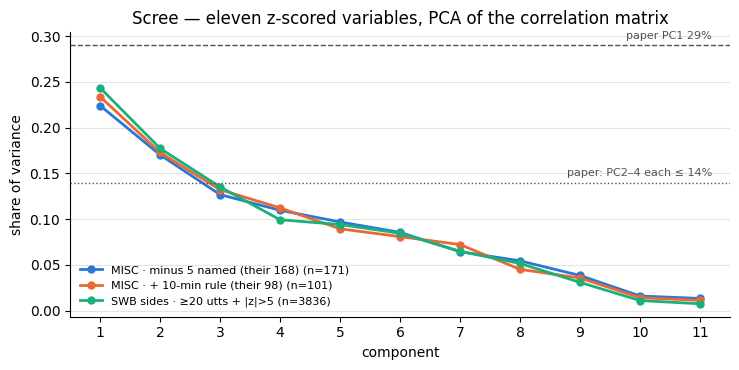

In [4]:
SHOW = ["MISC · minus 5 named (their 168)", "MISC · + 10-min rule (their 98)", "SWB sides · ≥20 utts + |z|>5"]
data = {("Table 2 (paper, n=168)", "PC1 29%"): [f"{w:+.2f}" for w in T2]}
for k in SHOW:
    r = runs[k]; l = r["load"].set_index("variable"); sh = r["shares"]; comps, lo, hi = r["comps"], r["comp_lo"], r["comp_hi"]
    top = f"{k} (n={r['res']['n']}, Horn K={comps.shape[1]})"
    data[(top, f"PC1 {sh[0]:.0%}")] = [f"{p:+.2f} [{a:+.2f}, {b:+.2f}]{'' if sm else ' ✗'}" for p, a, b, sm in zip(l.pc1, l.ci_lo, l.ci_hi, l.sign_match)]
    for j in range(1, comps.shape[1]):
        data[(top, f"PC{j + 1} {sh[j]:.0%}")] = [f"{p:+.2f} [{a:+.2f}, {b:+.2f}]" for p, a, b in zip(comps[:, j], lo[:, j], hi[:, j])]
L = pd.DataFrame(data, index=V); L.columns = pd.MultiIndex.from_tuples(L.columns)
display(L)
print("unit-norm eigenvectors of the correlation matrix, the Horn-retained ones only; column headers carry each component's share of variance.\n"
      "PC1 oriented wps > 0 (the paper's convention); PC2+ oriented so the largest loading is positive.\n"
      "[ ] = bootstrap 95% interval over units (B=500): for PC1 the eigenvalue-ranked first component of each resample (the object Table 2 reports);\n"
      "for PC2+ each resample's components are matched to the full-sample component by greatest |cosine| and sign-aligned, because higher components trade places in resamples.\n"
      "✗ = PC1 sign differs from Table 2.\n")
for k in runs:
    r = runs[k]["res"]; s = runs[k]["shares"]
    print(f"{k:40s} n={r['n']:5d}  φ={r['phi']:.3f}  signs {r['signs']}/11  PC1 {s[0]:.1%}  PC2–4 {s[1]:.1%} / {s[2]:.1%} / {s[3]:.1%}  Horn K={r['horn_K']}")
print("paper (n=168):                                          PC1 29%, '2–3 less important components each explaining 14% or less'")

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for k, c in zip(SHOW, ("#2a78d6", "#eb6834", "#1baf7a")):                     # fixed categorical order: blue, orange, aqua
    ax.plot(range(1, 12), runs[k]["shares"], "-o", color=c, lw=2, ms=5, label=f"{k} (n={runs[k]['res']['n']})")
ax.axhline(0.29, color="#52514e", lw=1, ls="--"); ax.text(11.2, 0.295, "paper PC1 29%", va="bottom", ha="right", fontsize=8, color="#52514e")
ax.axhline(0.14, color="#52514e", lw=1, ls=":");  ax.text(11.2, 0.145, "paper: PC2–4 each ≤ 14%", va="bottom", ha="right", fontsize=8, color="#52514e")
ax.set(xlabel="component", ylabel="share of variance", xticks=range(1, 12), title="Scree — eleven z-scored variables, PCA of the correlation matrix")
ax.grid(axis="y", color="#e5e4e0", lw=0.8); ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

**Reading the retained components.** On MISC (n = 171) PC2 (17%) sets the repetition pair against speech rate — repu .62, rept .54, boplen .37 against wps −.31: "repeats and pauses" versus "talks fast" — and PC3 (13%) puts between-own pauses, pronouns and pitch variance (boplen .51, ppron .44, pv .36) against loudness variance and repetition (lv −.46, rept −.34); PC4 (11%) is post-other pause almost alone (poplen .74). On the 101-case sample PC2 is the same component (repu .54, rept .44, boplen .46, wps −.37) but PC3 and PC4 rearrange (poplen .61 against boplen −.52; pv .51 against lv −.50), and the intervals beyond PC2 mostly cross zero: at n ≈ 100–170 the third and fourth components are barely determined, which is the scree plot's 13% / 11% shoulder read as sampling noise. On 3,836 Switchboard sides every component is tight except where PC4 and PC5 trade places (wps on PC4 [+.28, +.68], pv on PC4 [−.39, +.27]): PC2 (18%) is the between-own pause pair with its shared denominator (wpp .63, boplen .63, plus poplen .28 against olap −.29), PC3 (14%) is overlap with pitch variance and pronouns against post-other pause (olap .55, pv .42, ppron .33, poplen −.42), PC4 (10%) pronouns with speech rate (ppron .63, wps .60), PC5 (9%) the two variance measures with post-other pause (pv .55, lv .53, poplen .46). The paper's single "involvement" axis is PC1 in both corpora; what the other retained components carry differs by corpus, and on MISC they are not stable enough at the paper's n to name.

## 5 — Reliability: Cronbach's α and the GLB as they computed it

What the two numbers measure. **α** is the reliability of the eleven's unweighted sum *if* they all measure one thing with equal loadings (tau-equivalence): α = k·r̄ / (1 + (k − 1)·r̄), a function of the mean inter-item correlation r̄ alone — the paper's .67 implies r̄ ≈ .16. **The GLB** credits *all* common variance, however many dimensions it spreads over: it finds the largest error variance whose removal leaves the correlation matrix positive semidefinite and reports 1 − that / total variance of the sum. With eleven variables of which Horn keeps three to five components, the GLB is high largely *because* the set is multidimensional — the opposite of what "reliability of a single involvement scale" suggests. The tempting misreading is "GLB .85 ⇒ the eleven cohere at .85"; the arithmetic says "α .67 ⇒ they cohere at r̄ .16, and .85 of their summed variance is common to *some* set of factors".

`glb.fa` adds a second inflation of its own: it fits as many factors as the reduced matrix has positive eigenvalues — five or six of eleven here — and five-factor communalities on eleven items are high by construction. Both GLBs are also biased upward in small samples (ten Berge & Sočan 2004), so the last block runs the same routines on pure noise at the paper's n, where α ≈ 0 and the GLB is not. The paper's row carries its two published values; whether they were keyed is unstated.

In [5]:
rel = grid[["n", "alpha_raw", "alpha_keyed", "r_bar_keyed", "glb_fa_raw", "nf_raw", "glb_fa_keyed", "nf_keyed", "glb_fa_keyed_exact", "glb_alg_raw", "glb_alg_keyed", "omega_t"]].copy()
rel.loc["Thomas et al. 2018 (their code, n=168; keying unstated)"] = [168, np.nan, 0.67, 0.67 / (11 - 10 * 0.67), np.nan, np.nan, 0.85, np.nan, np.nan, np.nan, np.nan, np.nan]
rel = rel.astype({"n": int, "nf_raw": "Int64", "nf_keyed": "Int64"})
display(rel.round(3))
print("glb_fa = psych 1.7.3 glb.fa ported (nf = factors it fitted) · glb_fa_keyed_exact = same routine at the exact minres optimum · glb_alg = the algebraic bound · omega_t = one-factor ω\n")

print("α if one variable is deleted (keyed) — a variable whose removal RAISES α is pulling against the sum:")
aid = pd.DataFrame({k: runs[k]["load"].set_index("variable").alpha_if_deleted for k in SHOW})
aid.loc["(all eleven)"] = [runs[k]["res"]["alpha_keyed"] for k in SHOW]
display(aid.round(3))

rng = np.random.default_rng(0)
print("the same routines on pure noise (iid normal, 11 variables) — what the bound reports when nothing is there:")
for n, B in ((98, 200), (168, 200), (3836, 40)):
    gf, ga = zip(*[(tm.glb_fa(Rn)[0], tm.glb_algebraic(Rn)[0]) for Rn in (np.corrcoef(rng.standard_normal((n, 11)), rowvar=False) for _ in range(B))])
    print(f"  n={n:5d}: glb.fa median {np.median(gf):.2f} (95th pct {np.percentile(gf, 95):.2f}) · algebraic GLB median {np.median(ga):.2f} (95th {np.percentile(ga, 95):.2f}) · α ≈ 0 by construction")

,n,alpha_raw,alpha_keyed,r_bar_keyed,glb_fa_raw,nf_raw,glb_fa_keyed,nf_keyed,glb_fa_keyed_exact,glb_alg_raw,glb_alg_keyed,omega_t
sample,,,,,,,,,,,,
MISC · minus 5 named (their 168),171,0.460,0.525,0.091,0.752,5,0.778,5,0.822,0.793,0.814,0.596
MISC · + 10-min rule (their 98),101,0.488,0.563,0.105,0.753,5,0.784,5,0.799,0.821,0.843,0.624
MISC · + |z|>5 (project rule),100,0.436,0.603,0.121,0.731,5,0.799,5,0.818,0.816,0.863,0.661
SWB sides · ≥20 utts (no outlier rule),3929,0.488,0.357,0.048,0.717,5,0.657,5,0.719,0.751,0.698,0.552
SWB sides · ≥20 utts + |z|>5,3836,0.491,0.359,0.048,0.783,6,0.735,6,0.754,0.780,0.732,0.573
"Thomas et al. 2018 (their code, n=168; keying unstated)",168,NaN,0.670,0.156,NaN,<NA>,0.850,<NA>,NaN,NaN,NaN,NaN


glb_fa = psych 1.7.3 glb.fa ported (nf = factors it fitted) · glb_fa_keyed_exact = same routine at the exact minres optimum · glb_alg = the algebraic bound · omega_t = one-factor ω

α if one variable is deleted (keyed) — a variable whose removal RAISES α is pulling against the sum:


,MISC · minus 5 named (their 168),MISC · + 10-min rule (their 98),SWB sides · ≥20 utts + |z|>5
variable,,,
ppron,0.506,0.564,0.324
wps,0.427,0.475,0.264
wpu,0.410,0.448,0.173
wpp,0.416,0.473,0.436
boplen,0.529,0.578,0.476
poplen,0.544,0.570,0.378
pv,0.536,0.570,0.407
lv,0.511,0.540,0.348
olap,0.590,0.611,0.447


the same routines on pure noise (iid normal, 11 variables) — what the bound reports when nothing is there:


  n=   98: glb.fa median 0.41 (95th pct 0.54) · algebraic GLB median 0.38 (95th 0.52) · α ≈ 0 by construction


  n=  168: glb.fa median 0.39 (95th pct 0.49) · algebraic GLB median 0.30 (95th 0.43) · α ≈ 0 by construction


  n= 3836: glb.fa median 0.21 (95th pct 0.36) · algebraic GLB median 0.06 (95th 0.10) · α ≈ 0 by construction


## 6 — Involvement: the histogram of units on PC1, with fitted curves

The score is the unit-norm PC1 projection of the z-scored eleven, standardised — one number per participant-task (MISC) or per conversation side (Switchboard). Three curves on each histogram: a normal fit (the paper's "approximately normally distributed"), a skew-normal fit (three parameters; its shape α is 0 for a symmetric distribution and grows with the tail), and a kernel density estimate as the model-free reference. In each panel: sample skew and excess kurtosis, Hartigan's dip test (small p ⇒ evidence of more than one mode), and the Kolmogorov–Smirnov distance of each fit (the largest gap between the empirical and the fitted cumulative curve; smaller is closer). Bins by Freedman–Diaconis.

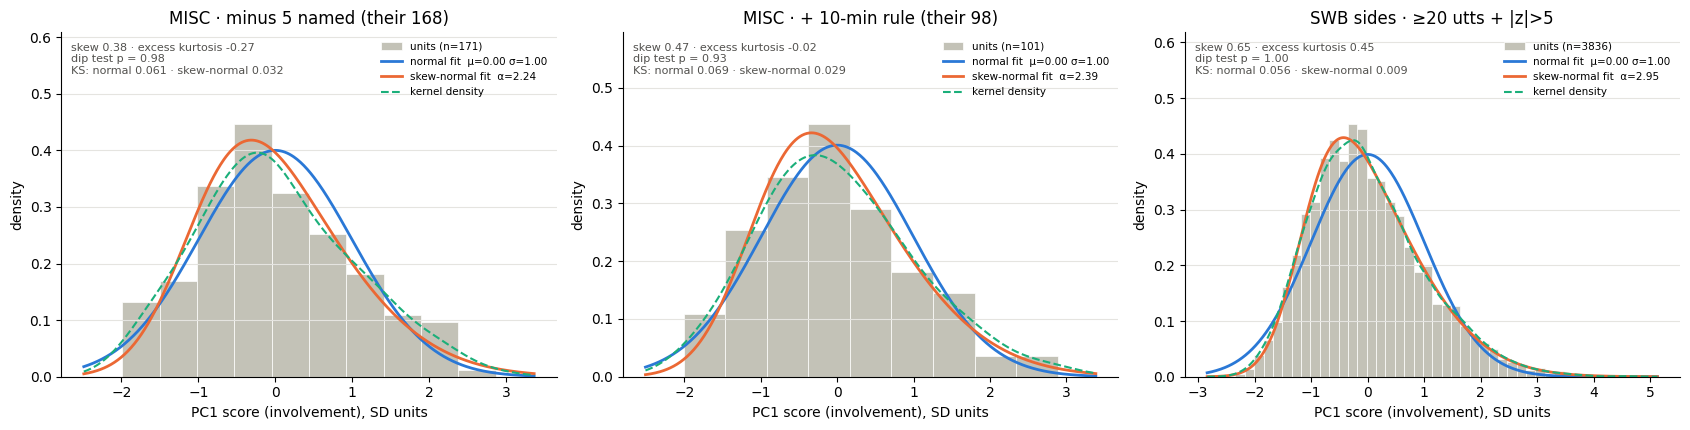

,n,skew,excess_kurtosis,skewnorm_shape,dip,dip_p,ks_normal,ks_skewnormal
MISC · minus 5 named (their 168),171,0.383,-0.268,2.235,0.018,0.984,0.061,0.032
MISC · + 10-min rule (their 98),101,0.473,-0.016,2.395,0.026,0.928,0.069,0.029
MISC · + |z|>5 (project rule),100,0.433,-0.037,2.146,0.022,0.991,0.066,0.032
SWB sides · ≥20 utts (no outlier rule),3929,0.663,0.483,2.948,0.003,0.997,0.055,0.008
SWB sides · ≥20 utts + |z|>5,3836,0.652,0.448,2.948,0.003,0.995,0.056,0.009


MISC · minus 5 named (their 168)         r(our PC1 score, Σ Table-2-weight × z) = 0.966
MISC · + 10-min rule (their 98)          r(our PC1 score, Σ Table-2-weight × z) = 0.992
MISC · + |z|>5 (project rule)            r(our PC1 score, Σ Table-2-weight × z) = 0.995
SWB sides · ≥20 utts (no outlier rule)   r(our PC1 score, Σ Table-2-weight × z) = 0.924
SWB sides · ≥20 utts + |z|>5             r(our PC1 score, Σ Table-2-weight × z) = 0.947


In [6]:
def fit_curves(u, ax=None, title=""):
    mu, sd = stats.norm.fit(u); a, loc, sc = stats.skewnorm.fit(u); kde = stats.gaussian_kde(u)
    dip, p = diptest.diptest(u)
    out = dict(n=len(u), skew=stats.skew(u), excess_kurtosis=stats.kurtosis(u), skewnorm_shape=a, dip=dip, dip_p=p,
               ks_normal=stats.kstest(u, "norm", args=(mu, sd)).statistic, ks_skewnormal=stats.kstest(u, "skewnorm", args=(a, loc, sc)).statistic)
    if ax is not None:
        x = np.linspace(u.min() - 0.5, u.max() + 0.5, 400)
        ax.hist(u, bins="fd", density=True, color="#c3c2b7", edgecolor="white", lw=0.5, label=f"units (n={len(u)})")
        ax.plot(x, stats.norm.pdf(x, mu, sd), color="#2a78d6", lw=2, label=f"normal fit  μ={mu + 0.0 if abs(mu) > 5e-3 else 0.0:.2f} σ={sd:.2f}")
        ax.plot(x, stats.skewnorm.pdf(x, a, loc, sc), color="#eb6834", lw=2, label=f"skew-normal fit  α={a:.2f}")
        ax.plot(x, kde(x), color="#1baf7a", lw=1.5, ls="--", label="kernel density")
        ax.set(title=title, xlabel="PC1 score (involvement), SD units", ylabel="density")
        ax.text(0.02, 0.97, f"skew {out['skew']:.2f} · excess kurtosis {out['excess_kurtosis']:.2f}\ndip test p = {p:.2f}\nKS: normal {out['ks_normal']:.3f} · skew-normal {out['ks_skewnormal']:.3f}",
                transform=ax.transAxes, va="top", fontsize=8, color="#52514e")
        ax.set_ylim(0, ax.get_ylim()[1] * 1.3)                                     # headroom for the annotation and legend
        ax.grid(axis="y", color="#e5e4e0", lw=0.8); ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False, fontsize=7.5, loc="upper right")
    return out

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
for ax, k in zip(axes, SHOW):
    fit_curves(runs[k]["u"], ax, k)
plt.tight_layout(); plt.show()
fits = pd.DataFrame({k: fit_curves(runs[k]["u"]) for k in runs}).T
display(fits.astype({"n": int}).round(3))
for k in runs:
    print(f"{k:40s} r(our PC1 score, Σ Table-2-weight × z) = {runs[k]['res']['r_ours_vs_table2_weights']:.3f}")

## 7 — Close

**What reproduced.** With the paper's five named cases removed (n = 171 against their 168), our PC1 of the eleven on the paper's own data has congruence φ = .94 with Table 2 and 10 of 11 signs — the exception is olap, +.09 here against −.01 there, the loading the paper itself called "practically zero". With the ten-minute rule as well (n = 101 against their 98), φ = .98; the involvement score under our loadings correlates .97 / .99 with the score under their published weights. PC1 explains 22–23% of variance (theirs 29%), PC2–4 17 / 13 / 11% (theirs "each 14% or less"); Horn keeps 4. The largest loading differences are rept and repu (.27 / .24 against .39 / .39 at n = 171; .38 / .34 at n = 101) and poplen (−.09 against −.27); the bootstrap intervals contain the paper's value for every variable at n = 101 and for all but poplen at n = 171 — and at n = 101 the rept / repu intervals cross zero, i.e. the first two components (23% vs 17%) trade places in resamples. That is the sampling error of an eleven-variable PCA at n ≈ 100, and it is why the score is more stable than the loadings.

**Reliability, as they computed it.** Cronbach's α keyed by Table 2's signs is .53 (n = 171) / .56 (n = 101) against their .67 (r̄ .09 / .11 against their implied .16); raw-signed α is .46 / .49, so the paper's α is only reachable with the variables keyed. `glb.fa` (psych 1.7.3, ported) fits five factors and gives .78 keyed on both samples (.75 raw); at the exact minres optimum .82 / .80; the algebraic GLB .81 / .84 — against their .85. On pure noise at n = 168 the same `glb.fa` gives .39 (95th percentile .49) and the algebraic bound .30 (.43): roughly half the distance from 0 to the paper's .85 is what an eleven-variable GLB reports on nothing at that n. The gap in α (.53 vs .67) is the substantive difference — on our routes the eleven cohere less than on theirs — and what coherence there is spreads over several components, which is exactly the situation in which a GLB sits far above α without saying anything about a single scale.

**The distribution on PC1.** Unimodal on every sample (dip test p ≥ .93), right-skewed (skew .38–.47 on MISC, .65 on Switchboard sides), light-tailed to normal on MISC (excess kurtosis −.27 to −.02), slightly heavy-tailed on Switchboard (.45). A normal fit sits within KS distance .06–.07 of the empirical distribution on MISC and .056 on Switchboard; a skew-normal (shape α ≈ 2.2–2.9) halves that on MISC (.03) and takes it to .009 on Switchboard. "Approximately normally distributed" is fair at the paper's n; on 3,836 sides the right tail is visibly the involved end and a symmetric curve misses it.

**Switchboard through the same method.** φ = .84 (9 / 11 signs; boplen and pv flip, both ≈ 0 in both studies), PC1 24%, Horn K = 5, keyed α .36 (r̄ .05), `glb.fa` .74 (six factors), algebraic GLB .73, involvement under their weights r = .95 with ours. The reading in `c_alpha/README.md` stands: the method reproduces the paper on its own data, so the Switchboard gap is corpus — rept / repu and wpu take over PC1, wpp collapses to .07 because Switchboard's between-own pause count shares a denominator with boplen — and it exceeds the paper's own sampling noise (subsample φ q05 .90 at n = 168, `thomas_method_results.csv`).

**Bookkeeping.** These are the same numbers as `c_alpha/*_results.csv` / `*_loadings.csv` where the samples coincide (`misc_method_*` = the n = 100 row, `thomas_method_*` = the n = 3,836 row). Not done: a bit-identical `glb.fa` (needs R; the exact-minres column bounds the difference at about .04), the three cleaning cases the paper does not name, and the caller-level pooling of the eleven into NB08 (`docs/AUDIT.md` §4E-h).

## 8 — Addendum (2026-10-06): how many components? Velicer's MAP and two other second opinions on Horn's K

**The question.** §4 keeps the components Horn's parallel analysis retains: five on the 3,836 Switchboard sides. Does a criterion that works differently also find five?

**Why Horn needs a second opinion at this n.** Horn keeps a component while its eigenvalue beats the 95th percentile of the same-rank eigenvalue in random data of the same size. That line falls toward 1 as n grows: eleven independent variables measured on 3,836 cases give eigenvalues between about 0.9 and 1.1. So at our n, Horn's question ("is this component bigger than noise?") becomes "is its eigenvalue above about 1.02?". That is Kaiser's eigenvalue-above-1 rule with a small margin. A second criterion should ask something else.

**Velicer's MAP** (minimum average partial; Velicer 1976; algorithm as in O'Connor 2000) asks how much correlation between the variables is left after the first m components are removed. For m = 0, 1, 2, …, it subtracts the first m principal components from the correlation matrix, rescales what is left to partial correlations, and averages their squares over the 55 pairs. K is the m at the minimum. The revision (Velicer, Eaton & Fava 2000) averages fourth powers instead, so large leftover correlations dominate and small ones barely count. While the removed components carry variance that several variables share, the leftover correlations shrink. Once a component mostly reflects one or two variables, removing it *creates* leftover correlation, and the average climbs. The curve estimates a population quantity, so unlike Horn it does not drift with n.

**MAP's blind spot** follows from one line of algebra. Take m equally correlated variables and remove their component: what is left between them is a partial correlation of exactly −1/(m − 1), whatever they correlated before. (The residual of an equicorrelation block after its first component is (1 − r)(I − 11ᵀ/m).) So MAP keeps such a component only if r > 1/(m − 1). A pair never qualifies (its partial goes to −1), a triplet needs r above .5, four variables need r above .33. That is the arithmetic behind MAP's documented tendency to underestimate when components have few variables (Zwick & Velicer 1986). The closed form is checked in `tests/test_c_alpha_method.py`.

**Two more criteria, with different blind spots:**

- **Empirical Kaiser criterion** (EKC; Braeken & van Assen 2017): reference eigenvalues from random-matrix theory, lowered at later ranks for the variance the earlier components took, and floored at 1.
- **Comparison data** (CD; Ruscio & Roche 2012): simulate populations with 1, 2, 3, … common factors that reproduce the observed correlations *and* each variable's own distribution. Add factors while that brings their samples' eigenvalues measurably closer to ours (one-sided Mann–Whitney at α = .30; population 10,000, 500 samples per step — the authors' defaults). Across its authors' 10,000 simulated datasets CD beat parallel analysis, MAP and other rules (87% correct). Its behaviour at our n is checked directly in §8.2. It is stochastic, so it runs here with ten seeds.

Auerswald & Moshagen (2019) advise settling on a K only where several such criteria agree.

§8.1 runs every criterion on §3's five samples. §8.2 shows how each one behaves at our n, on subsamples and on planted structures whose answer is known. §8.3 opens up the five Switchboard components.

,n,Horn (§3),Kaiser λ > 1,EKC,MAP 1976,MAP 2000,CD (modal),"CD, 10 seeds"
sample,,,,,,,,
MISC · minus 5 named (their 168),171,4,5,5,0,2,5,5 6 5 5 6 5 4 5 6 5
MISC · + 10-min rule (their 98),101,4,4,4,0,3,5,5 5 5 4 5 3 5 5 5 5
MISC · + |z|>5 (project rule),100,2,5,5,0,3,3,3 3 3 3 3 3 3 4 3 3
SWB sides · ≥20 utts (no outlier rule),3929,4,5,5,1,2,6,6 6 6 6 4 5 5 6 6 6
SWB sides · ≥20 utts + |z|>5,3836,5,5,5,1,2,6,5 6 6 3 6 6 6 6 6 6


SWB sides · ≥20 utts + |z|>5 (n = 3,836) — eigenvalue against Horn's line (95th percentile of 1,000 random datasets) and EKC's reference:


component,1,2,3,4,5,6,7
eigenvalue,2.680,1.951,1.488,1.093,1.035,0.93,0.713
Horn's line,1.108,1.078,1.058,1.041,1.024,1.01,0.996
EKC reference,1.110,1.000,1.000,1.000,1.000,1.00,1.000


MAP's curve — average partial correlation left after removing the first m components (K = the m at the minimum):


m,0,1,2,3,4,5,6
mean partial r² (1976),0.0572,0.0481,0.0632,0.0646,0.0826,0.1100,0.1577
mean partial r⁴ (2000),0.0300,0.0129,0.0126,0.0132,0.0310,0.0515,0.1010


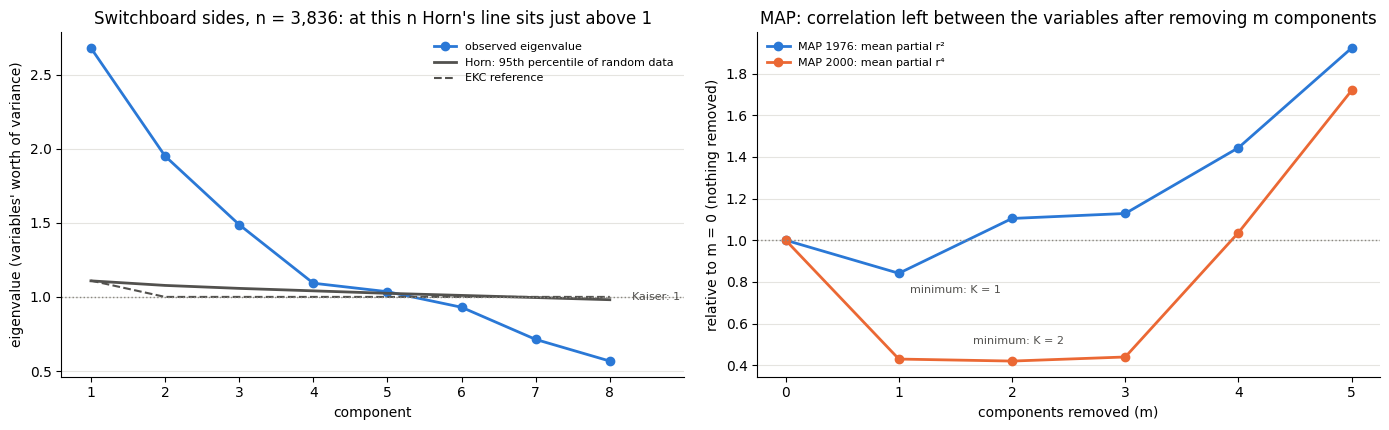

In [7]:
# §8.1 — Horn beside Velicer's MAP (1976: mean squared partial r; 2000: mean fourth power), the empirical Kaiser
# criterion and comparison data, on every sample of §3. Horn's K is §3's (tm.horn_k: normal null, 95th percentile).
# CD simulates its comparison populations, so it runs with CD_SEEDS seeds; the table shows the modal K and every run.
CD_SEEDS = 10
SWB = "SWB sides · ≥20 utts + |z|>5"
crit, curves = [], {}
for k in runs:
    R, Z, n = runs[k]["R"], runs[k]["Z"], runs[k]["res"]["n"]
    eig = np.sort(np.linalg.eigvalsh(R))[::-1]
    k76, k00, f2, f4 = tm.velicer_map(R)
    cd = [tm.comparison_data(Z, seed=s)[0] for s in range(CD_SEEDS)]
    curves[k] = dict(eig=eig, f2=f2, f4=f4)
    crit.append({"sample": k, "n": n, "Horn (§3)": runs[k]["res"]["horn_K"], "Kaiser λ > 1": int((eig > 1).sum()),
                 "EKC": tm.ekc(eig, n)[0], "MAP 1976": k76, "MAP 2000": k00, "CD (modal)": int(np.bincount(cd).argmax()),
                 f"CD, {CD_SEEDS} seeds": " ".join(map(str, cd))})
CRIT = pd.DataFrame(crit).set_index("sample")
display(CRIT)

def horn_line(Z, B=1000, seed=0):                    # Horn's 95th-percentile line itself (tm.horn_k returns only K)
    g = np.random.default_rng(seed)
    return np.percentile([np.sort(np.linalg.eigvalsh(np.corrcoef(g.standard_normal(Z.shape), rowvar=False)))[::-1] for _ in range(B)], 95, axis=0)

c, Zs = curves[SWB], runs[SWB]["Z"]
h_line, ekc_line = horn_line(Zs), tm.ekc(c["eig"], len(Zs))[1]
print(f"{SWB} (n = {len(Zs):,}) — eigenvalue against Horn's line (95th percentile of 1,000 random datasets) and EKC's reference:")
display(pd.DataFrame({"eigenvalue": c["eig"][:7], "Horn's line": h_line[:7], "EKC reference": ekc_line[:7]},
                     index=pd.Index(range(1, 8), name="component")).T.round(3))
print("MAP's curve — average partial correlation left after removing the first m components (K = the m at the minimum):")
with pd.option_context("display.precision", 4):
    display(pd.DataFrame({"mean partial r² (1976)": c["f2"][:7], "mean partial r⁴ (2000)": c["f4"][:7]},
                         index=pd.Index(range(7), name="m")).T)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.4))
r_ = np.arange(1, 9)
ax1.plot(r_, c["eig"][:8], "-o", color="#2a78d6", lw=2, ms=6, label="observed eigenvalue")
ax1.plot(r_, h_line[:8], color="#52514e", lw=2, label="Horn: 95th percentile of random data")
ax1.plot(r_, ekc_line[:8], color="#52514e", lw=1.5, ls="--", label="EKC reference")
ax1.axhline(1, color="#898781", lw=1, ls=":"); ax1.text(8.3, 1.0, "Kaiser: 1", va="center", fontsize=8, color="#52514e")
ax1.set(xlabel="component", ylabel="eigenvalue (variables' worth of variance)", xticks=r_, xlim=(0.6, 9),
        title=f"Switchboard sides, n = {len(Zs):,}: at this n Horn's line sits just above 1")
m_ = np.arange(6)
for f, col, lab, off in ((c["f2"], "#2a78d6", "MAP 1976: mean partial r²", (8, -14)), (c["f4"], "#eb6834", "MAP 2000: mean partial r⁴", (-28, 12))):
    ax2.plot(m_, f[:6] / f[0], "-o", color=col, lw=2, ms=6, label=lab)
    kk = int(f.argmin())
    ax2.annotate(f"minimum: K = {kk}", xy=(kk, f[kk] / f[0]), xytext=off, textcoords="offset points", fontsize=8, color="#52514e")
ax2.axhline(1, color="#898781", lw=1, ls=":")
ax2.set(xlabel="components removed (m)", ylabel="relative to m = 0 (nothing removed)", xticks=m_,
        title="MAP: correlation left between the variables after removing m components")
for ax in (ax1, ax2):
    ax.grid(axis="y", color="#e5e4e0", lw=0.8); ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

**Reading the criteria.** MAP does not give five. On the 3,836 Switchboard sides it keeps one component (1976) or two (2000). In the 2000 version, removing one, two or three components leaves almost the same average (.0129, .0126, .0132), and removing a fourth more than doubles it (.0310).

EKC and Kaiser's rule give five, but at this n they are not independent of Horn. The first table shows why: EKC's reference is exactly 1 from the second rank on, and Horn's line runs from 1.11 down to 1.02 over the first five ranks. All three ask whether an eigenvalue is above about 1, and the fifth (1.035) clears Horn's line by 0.011.

CD gives six in eight of ten runs. Six is the most it can test with eleven variables, so it agrees there is more than noise.

MISC (n = 100–171) splits the same way: MAP 0 (1976) or 2–3 (2000), Horn 2–4, CD 3–5. Horn on MISC drops from 4 to 2 when a single case leaves (n = 101 → 100), the instability of an eleven-variable PCA at that n.

Before reading MAP's low count as a verdict against five, §8.2 asks whether MAP *could* see five here.

In [8]:
# §8.2 — How each criterion behaves at this size. (a) Horn's and MAP's K on random subsamples of the Switchboard
# sides, from the paper's PCA n (168) up to 80% of ours. (b) Planted structures of our size whose answer is known:
# eleven variables, n = 3,836, one factor per block of variables, components carried by six variables down to two.
def k_dist(a):
    v, cnt = np.unique(a, return_counts=True)
    return " · ".join(f"{int(x)}: {cc / len(a):.0%}" for x, cc in zip(v, cnt))

SUB_B, rng8 = 50, np.random.default_rng(8)
by_n = {}
for m in (168, 500, 1000, 2000, int(0.8 * len(Zs))):
    ks = []
    for b in range(SUB_B):
        S = Zs[rng8.choice(len(Zs), m, replace=False)]
        ks.append((tm.horn_k(S, rng=np.random.default_rng(b)), *tm.velicer_map(np.corrcoef(S, rowvar=False))[:2]))
    ks = np.array(ks)
    by_n[f"n = {m:,}"] = {"Horn": k_dist(ks[:, 0]), "MAP 1976": k_dist(ks[:, 1]), "MAP 2000": k_dist(ks[:, 2])}
by_n[f"n = {len(Zs):,} (all)"] = {c_: str(CRIT.loc[SWB, k_]) for c_, k_ in (("Horn", "Horn (§3)"), ("MAP 1976", "MAP 1976"), ("MAP 2000", "MAP 2000"))}
print(f"(a) K on {SUB_B} random subsamples (without replacement) of the {len(Zs):,} Switchboard sides — share of subsamples giving each K:")
display(pd.DataFrame(by_n).T)

def planted(loads, n, rng):
    F = rng.standard_normal((n, len(loads)))
    return np.column_stack([l * F[:, j] + np.sqrt(1 - l * l) * rng.standard_normal(n) for j, block in enumerate(loads) for l in block])

STRUCT = {"2 factors on 6 + 5 variables, loadings .8 → .3": [[.8, .7, .6, .5, .4, .3], [.7, .6, .5, .4, .3]],
          "3 factors on 4 + 4 + 3 variables, loadings .8 → .3": [[.8, .6, .5, .4], [.7, .6, .4, .3], [.6, .5, .4]],
          "5 factors: a triplet (.9, .8, .7) + four pairs (.7, .7)": [[.9, .8, .7], [.7, .7], [.7, .7], [.7, .7], [.7, .7]]}
rng9, rows8 = np.random.default_rng(9), []
for name, loads in STRUCT.items():
    got = []
    for rep in range(10):
        Xp = planted(loads, len(Zs), rng9); Rp = np.corrcoef(Xp, rowvar=False); ep = np.sort(np.linalg.eigvalsh(Rp))[::-1]
        got.append((tm.horn_k(Xp, rng=np.random.default_rng(rep)), *tm.velicer_map(Rp)[:2], tm.ekc(ep, len(Xp))[0],
                    tm.comparison_data(Xp, seed=rep)[0]))
    got = np.array(got)
    rows8.append({"planted structure": name, "true K": len(loads),
                  **{c_: f"{(got[:, j] == len(loads)).mean():.0%} correct ({k_dist(got[:, j])})"
                     for j, c_ in enumerate(("Horn", "MAP 1976", "MAP 2000", "EKC", "CD"))}})
print(f"(b) planted structures, n = {len(Zs):,}, eleven variables, 10 draws each — share correct (and the K each criterion returned):")
with pd.option_context("display.max_colwidth", 60):
    display(pd.DataFrame(rows8).set_index("planted structure"))

(a) K on 50 random subsamples (without replacement) of the 3,836 Switchboard sides — share of subsamples giving each K:


,Horn,MAP 1976,MAP 2000
n = 168,3: 62% · 4: 38%,0: 26% · 1: 56% · 2: 12% · 3: 6%,1: 20% · 2: 56% · 3: 24%
n = 500,3: 28% · 4: 64% · 5: 8%,0: 20% · 1: 78% · 2: 2%,1: 22% · 2: 54% · 3: 24%
"n = 1,000",3: 8% · 4: 74% · 5: 18%,0: 2% · 1: 96% · 2: 2%,1: 20% · 2: 70% · 3: 10%
"n = 2,000",4: 72% · 5: 28%,1: 100%,1: 30% · 2: 42% · 3: 28%
"n = 3,068",4: 20% · 5: 80%,1: 100%,1: 34% · 2: 56% · 3: 10%
"n = 3,836 (all)",5,1,2


(b) planted structures, n = 3,836, eleven variables, 10 draws each — share correct (and the K each criterion returned):


,true K,Horn,MAP 1976,MAP 2000,EKC,CD
planted structure,,,,,,
"2 factors on 6 + 5 variables, loadings .8 → .3",2,100% correct (2: 100%),100% correct (2: 100%),100% correct (2: 100%),100% correct (2: 100%),90% correct (2: 90% · 3: 10%)
"3 factors on 4 + 4 + 3 variables, loadings .8 → .3",3,100% correct (3: 100%),0% correct (0: 20% · 1: 80%),0% correct (1: 100%),100% correct (3: 100%),60% correct (3: 60% · 4: 30% · 5: 10%)
"5 factors: a triplet (.9, .8, .7) + four pairs (.7, .7)",5,100% correct (5: 100%),0% correct (1: 100%),0% correct (1: 70% · 2: 30%),100% correct (5: 100%),40% correct (5: 40% · 6: 60%)


**Reading the behaviour.**

**(a) Horn's K grows with the sample:** 3–4 at the paper's n = 168, 4 from n ≈ 500, and 5 in 80% of subsamples at n = 3,068 and at the full 3,836. Noise would do the opposite. As n grows, Horn's line tightens around 1 and a pure-noise eigenvalue settles below it, so a noise component gets retained *less* often. The fifth component is therefore real but small: it is reliably detectable only from about 3,000 sides. MAP's K does not move with n (1976: 1 from n = 1,000 up; 2000: 1–3 throughout), as a population criterion should behave.

**(b) The planted structures settle what MAP's low count means.** At our size (eleven variables, n = 3,836), Horn and EKC recover all three planted structures in 10 of 10 draws. That includes the one built like ours: a strong triplet plus four pairs, five factors in all. MAP returns 1 on that five-factor structure in every draw (the 2000 version 1–2). It also misses the three-factor structure (blocks of 4, 4 and 3, loadings .8 down to .3). This is the −1/(m − 1) arithmetic at work.

So MAP's 1–2 on Switchboard is what it would report whether or not five components are there. It cannot corroborate five, and it cannot refute it either. CD over-extracts at this n: 60% and 40% correct on the last two structures, and every miss is one or two components too many. Its six is an upper reading, not a check. The criterion that is accurate at our size and shape is Horn's, with EKC agreeing.

In [9]:
# §8.3 — What the five Switchboard components are made of (§4's unit-norm weights), and every criterion again once
# the arithmetic duplicates go: wpp shares its denominator (the between-own pause count) with boplen, and repu
# restates rept. Then the correlations that the first four components imply for PC5's variables, against the data.
Rs, comps = runs[SWB]["R"], runs[SWB]["comps"]
anat = []
for j in range(comps.shape[1]):
    top = np.argsort(-np.abs(comps[:, j]))[:3]
    anat.append({"component": f"PC{j + 1}", "eigenvalue": round(c["eig"][j], 3),
                 "three largest weights": ", ".join(f"{V[t]} {comps[t, j]:+.2f}" for t in top),
                 "raw r among those three": ", ".join(f"{V[a]}–{V[b]} {Rs[a, b]:+.2f}" for i_, a in enumerate(top) for b in top[i_ + 1:])})
with pd.option_context("display.max_colwidth", 120):
    display(pd.DataFrame(anat).set_index("component"))

dup = []
for drop in [(), ("wpp",), ("repu",), ("wpp", "repu")]:
    keep = [V.index(v) for v in V if v not in drop]
    Zd = Zs[:, keep]; Rd = np.corrcoef(Zd, rowvar=False); ed = np.sort(np.linalg.eigvalsh(Rd))[::-1]
    k76, k00, _, _ = tm.velicer_map(Rd)
    cd = [tm.comparison_data(Zd, seed=s)[0] for s in range(CD_SEEDS)]
    dup.append({"variables": "all eleven" if not drop else "without " + " and ".join(drop), "p": len(keep),
                "Horn": tm.horn_k(Zd, rng=np.random.default_rng(0)), "λ₅ vs Horn's line": f"{ed[4]:.3f} vs {horn_line(Zd)[4]:.3f}",
                "Kaiser λ > 1": int((ed > 1).sum()), "EKC": tm.ekc(ed, len(Zd))[0], "MAP 1976": k76, "MAP 2000": k00,
                "CD (modal)": int(np.bincount(cd).argmax()), f"CD, {CD_SEEDS} seeds": " ".join(map(str, cd))})
print(f"every criterion on the {len(Zs):,} sides, with and without the arithmetic duplicates (r wpp–boplen {Rs[V.index('wpp'), V.index('boplen')]:+.2f}, "
      f"rept–repu {Rs[V.index('rept'), V.index('repu')]:+.2f}):")
display(pd.DataFrame(dup).set_index("variables"))

w_, v_ = np.linalg.eigh(Rs); o_ = np.argsort(w_)[::-1]
L4 = (v_[:, o_] * np.sqrt(w_[o_]))[:, :4]; implied = L4 @ L4.T
print("PC5's variables — correlation implied by the first four components vs observed: "
      + "; ".join(f"{a}–{b} {implied[V.index(a), V.index(b)]:+.2f} vs {Rs[V.index(a), V.index(b)]:+.2f}" for a, b in (("pv", "poplen"), ("lv", "poplen"), ("pv", "lv"))))

,eigenvalue,three largest weights,raw r among those three
component,,,
PC1,2.680,"rept +0.58, repu +0.55, wpu +0.51","rept–repu +0.91, rept–wpu +0.73, repu–wpu +0.65"
PC2,1.951,"boplen +0.63, wpp +0.63, olap -0.29","boplen–wpp +0.83, boplen–olap -0.12, wpp–olap -0.11"
PC3,1.488,"olap +0.55, poplen -0.42, pv +0.42","olap–poplen -0.40, olap–pv +0.15, poplen–pv -0.03"
PC4,1.093,"ppron +0.63, wps +0.60, poplen +0.29","ppron–wps +0.21, ppron–poplen -0.04, wps–poplen -0.10"
PC5,1.035,"pv +0.55, lv +0.53, poplen +0.46","pv–lv +0.05, pv–poplen -0.03, lv–poplen -0.04"


every criterion on the 3,836 sides, with and without the arithmetic duplicates (r wpp–boplen +0.83, rept–repu +0.91):


,p,Horn,λ₅ vs Horn's line,Kaiser λ > 1,EKC,MAP 1976,MAP 2000,CD (modal),"CD, 10 seeds"
variables,,,,,,,,,
all eleven,11,5,1.035 vs 1.024,5,5,1,2,6,5 6 6 3 6 6 6 6 6 6
without wpp,10,4,0.975 vs 1.017,4,4,1,1,4,4 5 4 5 4 5 4 4 4 5
without repu,10,5,1.033 vs 1.017,5,5,0,3,5,5 5 5 5 5 5 5 3 5 5
without wpp and repu,9,4,0.973 vs 1.010,4,4,0,2,5,5 5 4 5 5 5 5 5 5 5


PC5's variables — correlation implied by the first four components vs observed: pv–poplen -0.25 vs -0.03; lv–poplen -0.24 vs -0.04; pv–lv +0.09 vs +0.05


**What the five are.** Weights are §4's unit-norm weights; the correlations are raw correlations among each component's three heaviest variables.

- **PC1** (eigenvalue 2.68) is the only component whose variables correlate strongly with one another: rept, repu and wpu, r .65–.91. It is also the only one MAP counts.
- **PC2** (1.95) is boplen with wpp, r .83. The two share a denominator, the between-own pause count. This is the project's documented arithmetic pair (`c_alpha/README.md`; on telephone audio both measure tracker dropout).
- **PC3** (1.49) sets overlap against post-other pause (r −.40), with pitch variance alongside.
- **PC4** (1.09) is pronouns with speech rate (r .21).
- **PC5** (1.04) is pitch variance, loudness variance and post-other pause, which do not correlate with one another at all (|r| ≤ .05). Read on its own, PC5 undoes correlations the first four components imply but the data lack: pv–poplen −.25 implied vs −.03 observed, lv–poplen −.24 vs −.04.

Unrotated components are unique only as a subspace, so this does not make PC5 noise. It does mean PC5 is not a bundle of co-varying behaviours. Whether the five-dimensional subspace holds five interpretable directions is a rotation question, not a retention question.

**The arithmetic pair is what moves the count.** Without wpp, Horn, Kaiser, EKC and CD's modal answer all give four (λ₅ .975 against Horn's line 1.017). Without repu, everything stays at five. Without both, four (CD: five).

**What can be claimed.**

1. **Five components exceed noise** on 3,836 Switchboard sides (Horn's parallel analysis). The empirical Kaiser criterion agrees. Comparison data agrees as a lower bound (modal six, and it over-extracts at this n). On planted data of our size, Horn and EKC recovered every planted structure, including one built like ours.
2. **Velicer's MAP retains one (revised MAP: two).** Report it with its limitation, not as a disconfirmation. On a planted five-factor structure of our size and shape MAP also returns one, because it cannot count components carried by two or three variables (Zwick & Velicer 1986; the −1/(m − 1) arithmetic above).
3. **One of the five is arithmetic.** With wpp removed (it shares the between-own pause count with boplen), every criterion that gave five gives four. The count of non-arithmetic dimensions is four.
4. **The fourth and fifth are small.** Their eigenvalues are 1.09 and 1.04, roughly one variable's worth of variance each. The fifth is reliably detectable only from about 3,000 sides; at the paper's n = 168 Horn finds 3–4.

**Suggested wording:** *Horn's parallel analysis retained five components on 3,836 Switchboard sides, in agreement with the empirical Kaiser criterion and with comparison data. Velicer's MAP retained one (revised MAP: two). On simulated data of the same size and structure MAP likewise retained one where five factors were planted, so we read its count as a known limitation of MAP with components defined by two or three variables. One retained component reflects the shared denominator of wpp and boplen; with wpp removed, four components are retained by every criterion.*

**What would strengthen the claim further.** Not another retention rule: at this n they split into criteria that see small components (Horn, EKC, CD) and one that cannot (MAP), and both answers are already in. Instead:

- **Merge or drop the arithmetic twins** (wpp/boplen, rept/repu) *before* counting.
- **Give each hypothesised dimension three or more indicators** that are not arithmetic relatives of one another. MAP and a common-factor model can only see a dimension that has them.
- **Confirm on held-out data.** Name the dimensions on one random half of the sides, then test that structure on the other half. Each half has 1,918 sides, below the roughly 3,000 at which the fifth component becomes reliably detectable — so expect four to replicate cleanly and the fifth to be the test.